When you want to test something, first you have to understand your H0 and H1
Supposing that H0 is True - > See with a test, how probable is it that the data arises from our Assumptions (H0 True)
Genes independent  + Data of Genes => Make permutation test
### p-value = is the probability to get a more extreme result than the one observed
Calculate p value (Permutations with more correlation than original data / amount of permutations)

In [66]:
import pandas as pd
import numpy as np
from plotnine import *

growth_analysis = (pd.read_csv("growth_analysis.txt", sep = '\t')
.rename(columns = {'gene_5211': 'gene_A',
'gene_5091': 'gene_B',
'gene_1653': 'gene_C'})
.loc[:, ['strain', 'growth_rate', 'gene_A', 'gene_B', 'gene_C']])
growth_analysis.head()

,strain,growth_rate,gene_A,gene_B,gene_C
0,seg_01B,6.720447,False,False,True
1,seg_01C,7.429273,False,False,True
2,seg_01D,6.905589,True,True,False
3,seg_02B,4.924324,False,True,False
4,seg_02C,4.413402,False,False,True


a) A researcher collects data on the height (measured in cm) and weight (measured in g) of Germans.
She hypothesizes that there is a significant association between how tall Germans are and how much
they weigh. She would like to test this hypothesis without making any distributional assumptions.
- We are not making any distributional assumptions so let's use Spearman

b) A researcher collects data on the weight (measured in g) of Bavarians before and after the Oktoberfest. She would like to know whether there is a significant difference in average weight after
2 the Oktoberfest as compared to before it. Prior research indicates that the weight of Bavarians is approximately normally distributed.
- Binary data but not sure if Normally distributed or not. t-test is good.

c) A researcher is evaluating a rapid antigen test. The company manufacturing the test claims that if
someone is infected, the test will correctly return a positive result 99% of the time. The researcher
hypothesizes that, in practice, the test is often improperly administered and therefore significantly
less sensitive. She asks 1000 individuals, which have all been confirmed to be infected by a PCR
test, to self-administer the antigen test. She records how often the antigen test correctly returns a
positive result.
- We would use binomial test for only one binary, x =  # antigen positive result
- This time, the assumption H0 that we are trying to test is that the medicine is 99% efficient. We would use left side test. We will be testing wheter the effectiveness per 1000 people is 990. The p value needs to be 99%.

d)  The company manufacturing the test has collected a bigger dataset, comprising both infected and
non-infected individuals. For each individual, they record two datapoints: the result of a PCR
test (infected/not-infected), which is taken as ground truth, and the result of a self-administered
antigen test (positive/negative). They would like to show that, even if self-administered, the test
still gives some information about infection status and thus is better than nothing.
- We have two categorical binary values which allows us to make a 2x2 contingency table. We would use Fisher's exact test.


| Test Name              | Variable 1 Type | Variable 2 Type | Purpose / What It Compares                               | Notes                              |
|------------------------|-----------------|-----------------|-----------------------------------------------------------|------------------------------------|
| **t-test (general)**   | Continuous      | Binary group     | Mean difference between two groups                        | Requires normality, equal variances |
| **Welch’s t-test**     | Continuous      | Binary group     | Mean difference between two groups (unequal variances)    | More robust than t-test            |
| **Mann–Whitney U**     | Continuous/Ordinal | Binary group  | Distribution / median difference between two groups       | Nonparametric                      |
| **Wilcoxon Signed-Rank** | Continuous/Ordinal (paired) | Condition (before/after) | Paired difference in medians                               | Nonparametric                      |
| **Pearson correlation** | Continuous     | Continuous      | Linear relationship                                       | Sensitive to outliers; requires linearity |
| **Spearman correlation** | Ordinal or Continuous | Ordinal or Continuous | Monotonic relationship                                    | Rank-based, nonparametric          |
| **Fisher’s Exact Test** | Binary/Category | Binary/Category | Association between two categorical variables             | For small samples (2×2 tables)     |


## Section 02

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


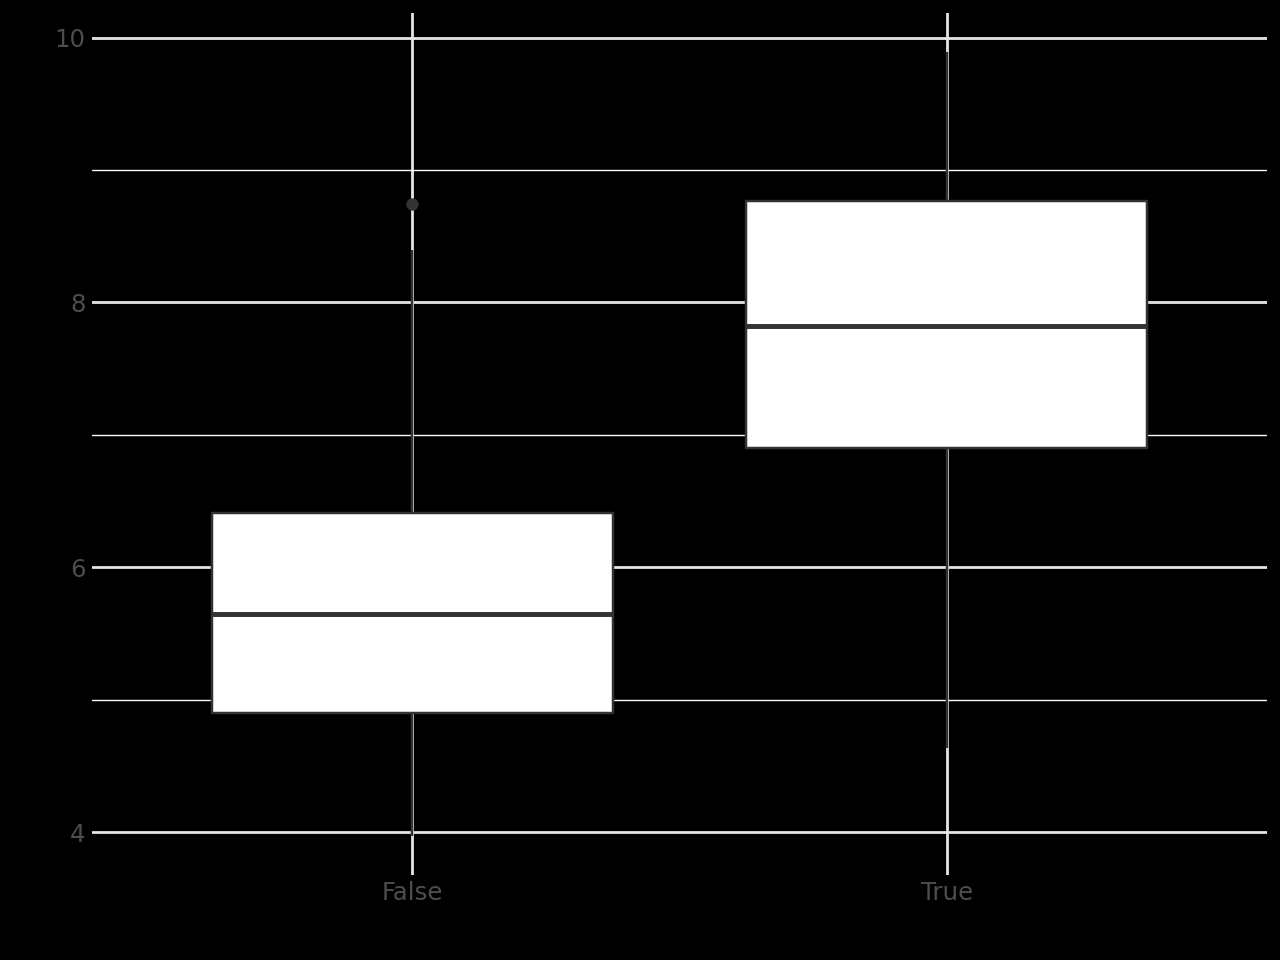

In [67]:
def plot_growth_one_mk(growth_analysis, gene):
    plot = (ggplot(growth_analysis, aes(gene, 'growth_rate')) +
            geom_boxplot() +
            xlab(f"Genotype at {gene}") +
            ylab("Growth rate in Maltose [Generations/day]") +
            theme_minimal()
            )
    return plot
plot_growth_one_mk(growth_analysis, 'gene_A')

2. Last week, using permutation, we saw that some genes are associated with growth. Which of the
statistical tests from the lecture would you use to test this association?
For each gene, we are not certain if it has a positive or negative effect on growth; therefore, which kind
of alternative hypothesis would you choose: double-sided, right or left? Apply the test(-s) to gene A to
obtain a p-value and see if the association that we found last week still holds. If more than one of the
3
tests are appropriate, specify, what are the assumptions, that you are doing in each case, use them all
and compare the results.

In [68]:
gA_false = growth_analysis.loc[growth_analysis['gene_A'] == False, 'growth_rate'].dropna()
gA_true  = growth_analysis.loc[growth_analysis['gene_A'] == True,  'growth_rate'].dropna()

len(gA_false), len(gA_true)


(74, 80)

#### We can use the Two-sample t-test.
- Applicable when growth is continuous and gene A defines two groups
- Null: mean growth reate is equal in both groups
- Assumptions: Independence of observations, normality
- Comment: More powerful than permutation if assumptions hold

#### Wilcoxon rank-sum test
- Same as t-test but normality is questionable
- Assumptions: Indepencence, Same distributional shape under the null
- Comment: Less assumption-free than permutation

In [69]:
from scipy.stats import mannwhitneyu

def test_growth(gene_name, test = 'wilcoxon'):
    g_false = growth_analysis.loc[growth_analysis[f'gene_{gene_name}'] == False, 'growth_rate'].dropna()
    g_true  = growth_analysis.loc[growth_analysis[f'gene_{gene_name}'] == True,  'growth_rate'].dropna()
    if test == 'wilcoxon':
        stats, pval = mannwhitneyu(
        g_false,
        g_true,
        alternative='two-sided'
    )
    elif test == 'ttest':
        stats, pval = ttest_ind(g_false, g_true, alternative='two-sided', equal_var=False)
    else:
        return Exception("Test not found")
    return pval

In [70]:
from scipy.stats import ttest_ind

p_ttest = test_growth(gene_name = "B", test = 'ttest')
p_ttest


np.float64(0.0006307450542089743)

In [71]:
from scipy.stats import mannwhitneyu

p_wilcox = test_growth("A", test = 'wilcoxon')
p_wilcox


np.float64(2.2643864924854154e-16)

# Section 03
Investigate the Pearson correlation between Sepal.Length and Sepal.Width within the iris dataset
(you can load the dataset from seaborn library using load_dataset({dataset_name}) function). Calculate the correlation and plot your results. Are there any issues with your results? Discuss.

PearsonRResult(statistic=np.float64(-0.11756978413300206), pvalue=np.float64(0.1518982607114476))


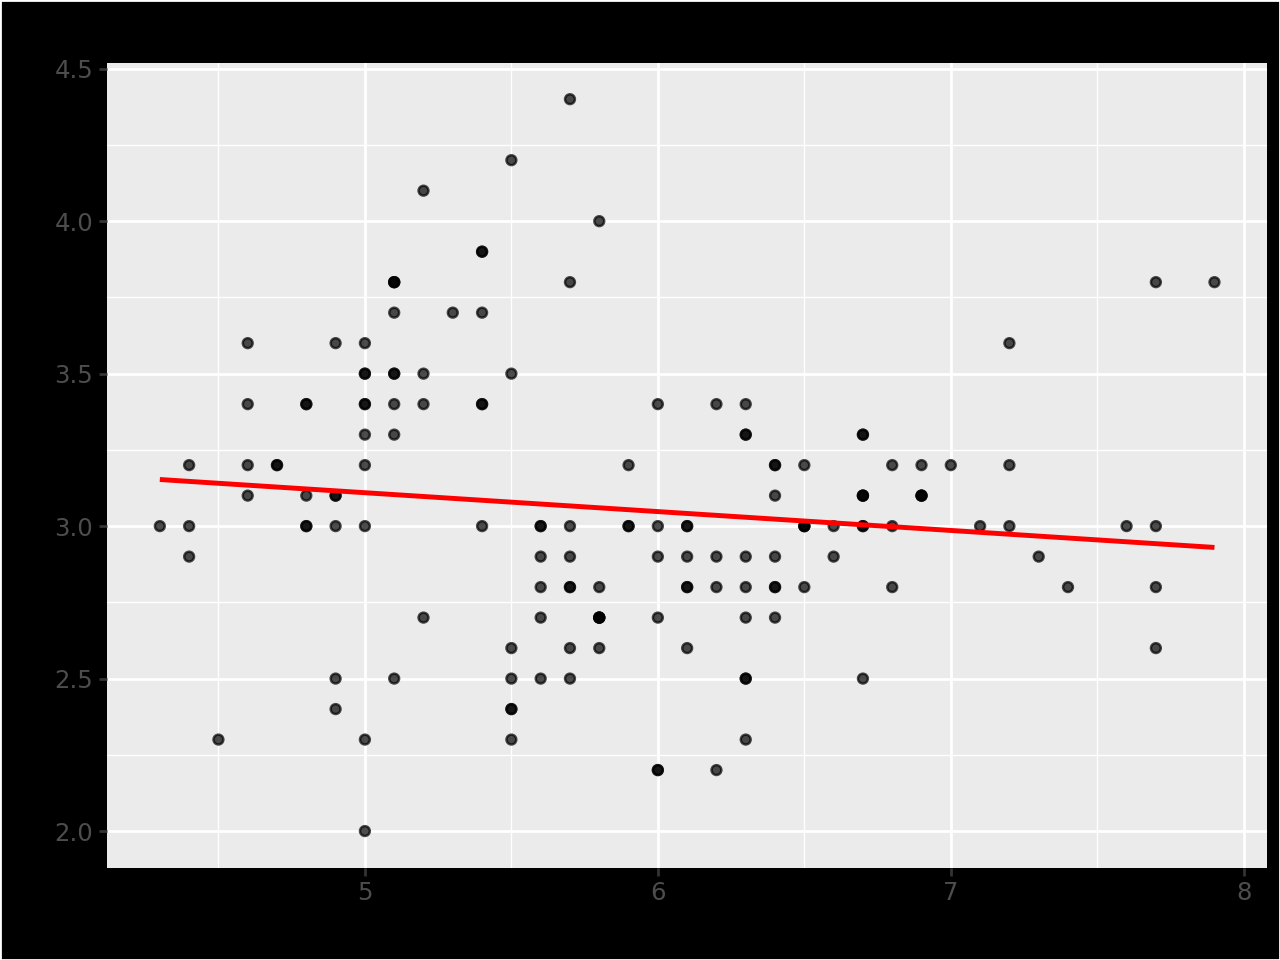

In [72]:
from sklearn.datasets import load_iris
from scipy.stats import pearsonr

iris = load_iris(as_frame=True)['frame']
sepal_length = iris['sepal length (cm)']
sepal_width = iris['sepal width (cm)']
print(pearsonr(sepal_length, sepal_width))

from plotnine import *

(
    ggplot(iris, aes(x='sepal length (cm)', y='sepal width (cm)'))
    + geom_point(alpha=0.7)
    + geom_smooth(method='lm', se=False, color='red')
    + labs(
        title="Sepal Length vs Sepal Width (Iris dataset)",
        x="Sepal Length (cm)",
        y="Sepal Width (cm)"
    )
)

# The issue with these results is that the dataset includes three different species


In [73]:
sepal_length = iris.loc[iris['target'] == 2, 'sepal length (cm)']
sepal_width = iris.loc[iris['target'] == 2, 'sepal width (cm)']

pearsonr(sepal_length, sepal_width)

# The pearson, when grouped by species is much higher.

PearsonRResult(statistic=np.float64(0.45722781639411314), pvalue=np.float64(0.0008434624723708724))

### Section 04 - Warmup: correctly specifying a test
1. A clinical trial was conducted in datavizland to test the efficacy of a new vaccine in preventing viral
infection. The results are summarized in the following contingency table:

##### Infected False True
##### Vaccinated
##### False 0 30
##### True 60 10

Suggest an appropriate statistical test, state the null hypothesis and the alternative. Justify, in one
sentence, why you used this test.
- We can use Fisher's exact test. Null: Vaccination status and outcome are independent. I used this test because it makes no assumptions of normality, the data is categorical and the observations seem to be independent.

### Section 05.1
The file stats-pitfalls.csv contains simulated data that will help us analyze how the t-test can
fail. Load and visualize the data. Use the vizualization approach, that you’ve learned during previous
lectures, to assess the hypothesis, that the data comes from normal distribution. Apply both the t-test
and Wilcoxon test on it.
What do you observe? Which test is the better choice here?

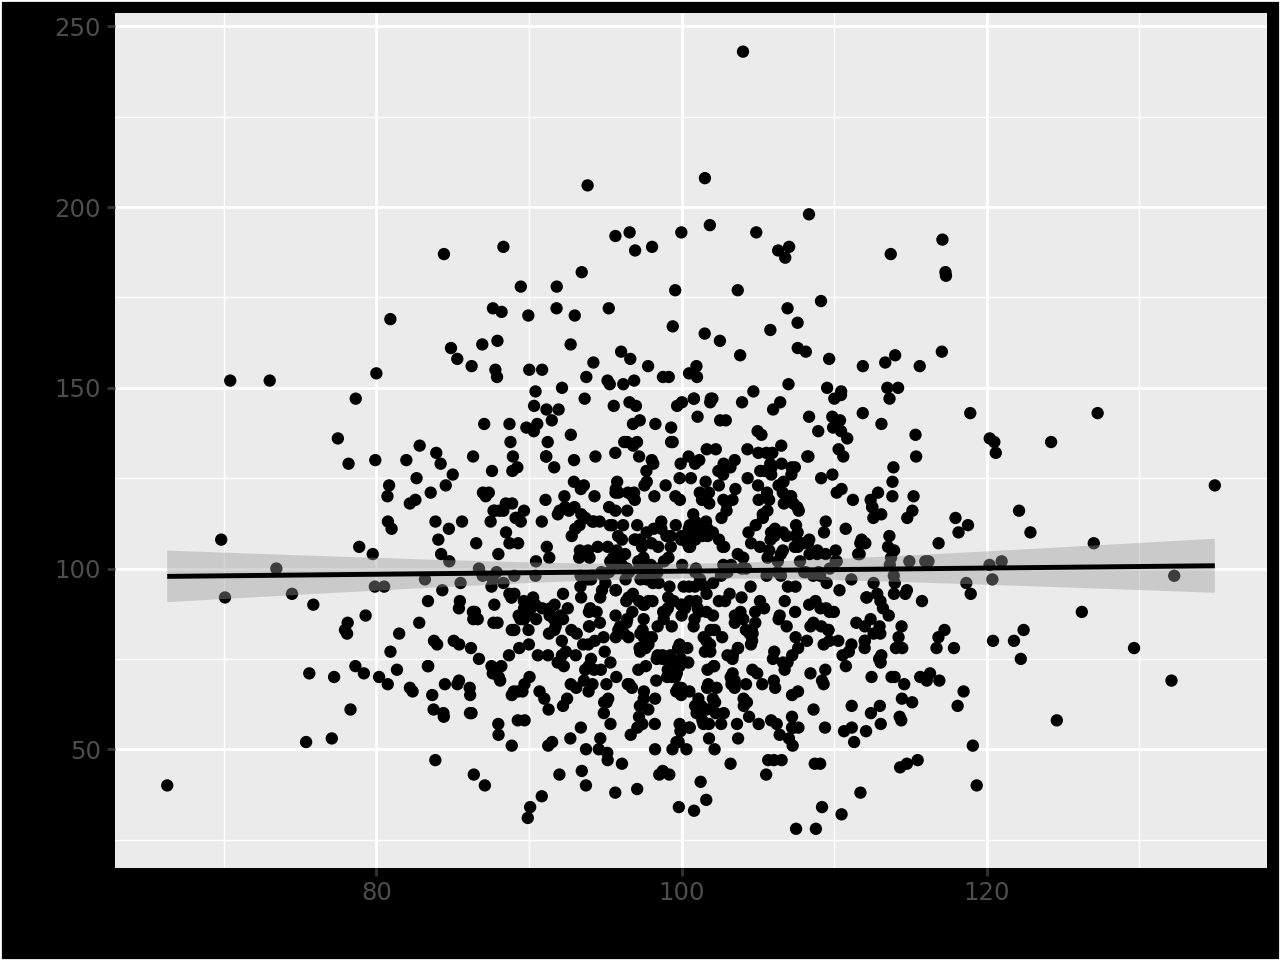

In [74]:
stats_pitfalls = (pd.read_csv("stats-pitfalls.csv", sep = ' '))
stats_pitfalls.head()

(ggplot(stats_pitfalls, aes(x = 'group1', y = 'group2')) + geom_point() +
 geom_smooth(method = 'lm'))


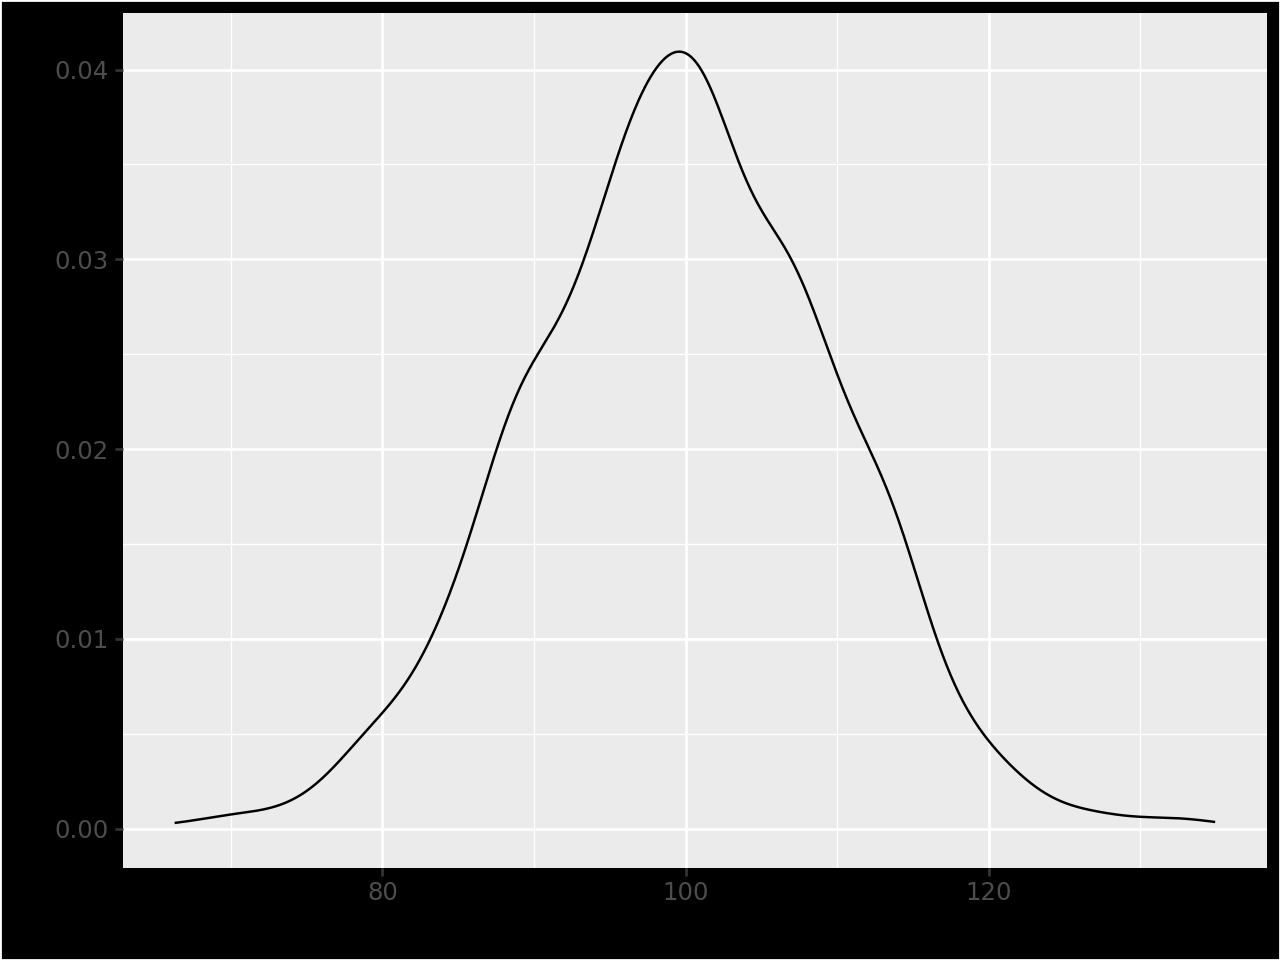

In [75]:
ggplot(stats_pitfalls, aes(x='group1')) + geom_density()


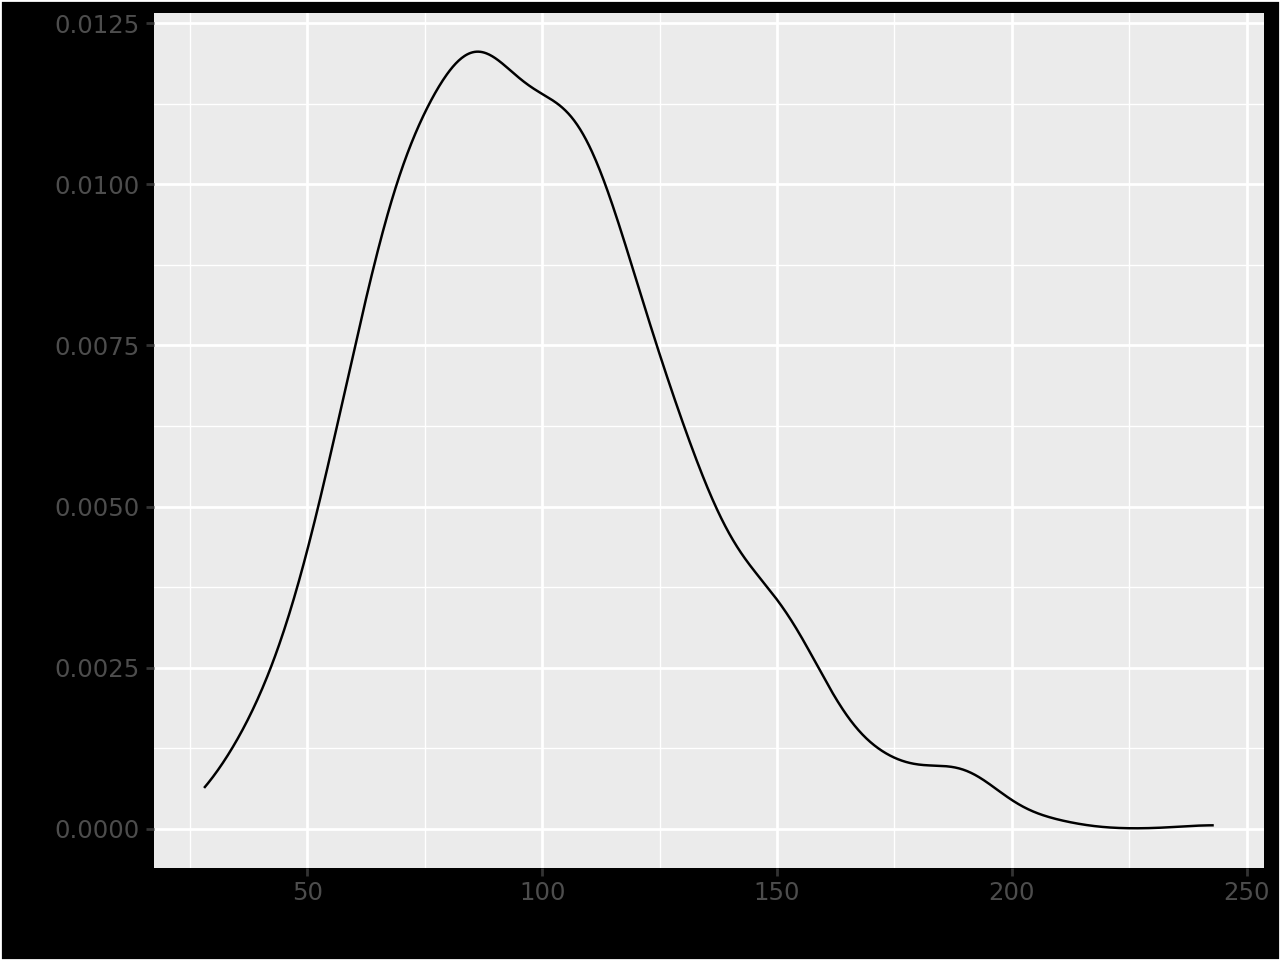

In [76]:
ggplot(stats_pitfalls, aes(x='group2')) + geom_density()


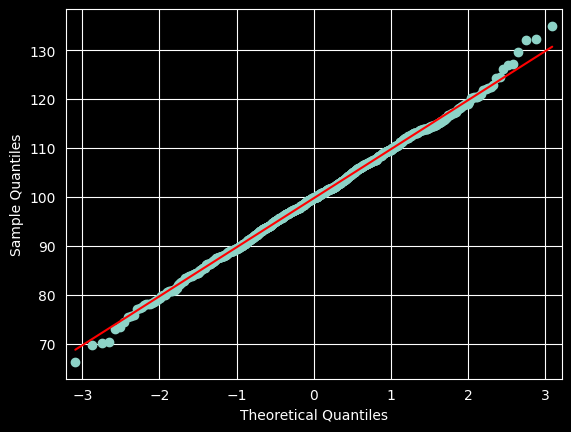

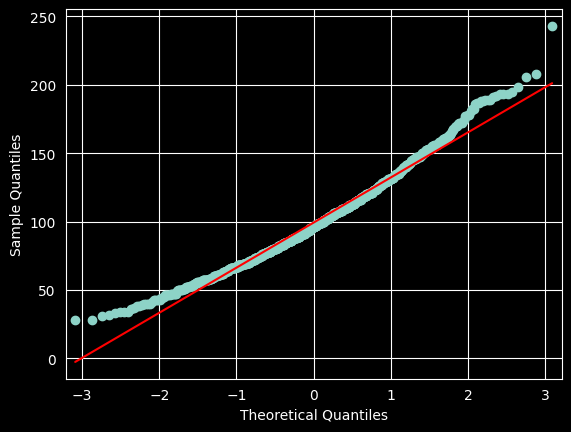

In [77]:
import statsmodels.api as sm
import pylab as py

sm.qqplot(stats_pitfalls['group1'], line='s')
py.show()

sm.qqplot(stats_pitfalls['group2'], line='s')
py.show()


Group 1 seems to very closely follow the normal distribution while Group 2 deviates on the tails.

In [78]:
group1 = stats_pitfalls['group1']
group2 = stats_pitfalls['group2']

# t-test
stats, pval = ttest_ind(group1, group2, alternative='two-sided', equal_var=False)
print(pval)

# Wilcoxon rank-sum test
stats, pval = mannwhitneyu(
    group1,
    group2,
    alternative='two-sided'
)
print(pval)


0.6625758141332032
0.0015949050596973065


I seem to be getting a very high pvalue when not taking the ranking into account (t-test) and a very low pvalue when ranking the results beforehand (wilcoxon rank-sum)
This result seems to confirm the assumption that is placed before t-tests are done: both datasets need to have normal distribution, in this case group2 did not have normal distribution and thus some other factors in the dataset made it seem like the datasets are entirely different (high pvalue), but we can see from the previous schema that they are very similar.

### Section 05.2
In dataviz land, we want to know whether there is correlation between attendance to the exercise
sessions and the points achieved in the final exam. We provide simulated data below.
Load the data from exam_correlation.tsv. Calculate the correlation between attendance and points
using Pearson and Spearman methods and visualize it. Some students will drop out of the distribution
since they were planning to take the retake exam and skipped the first exam, thus obtaining a grade of
zero.
Which correlation method should be preferred in this context and why?

In [79]:
exam_correlation = (pd.read_csv("exam_correlation.tsv", sep = ' '))
exam_correlation.head()

,attendance,achieved_points
0,76.629728,0.000000
1,42.640913,45.506498
2,58.932917,65.820449
3,63.669267,77.600978
4,59.655306,43.162913


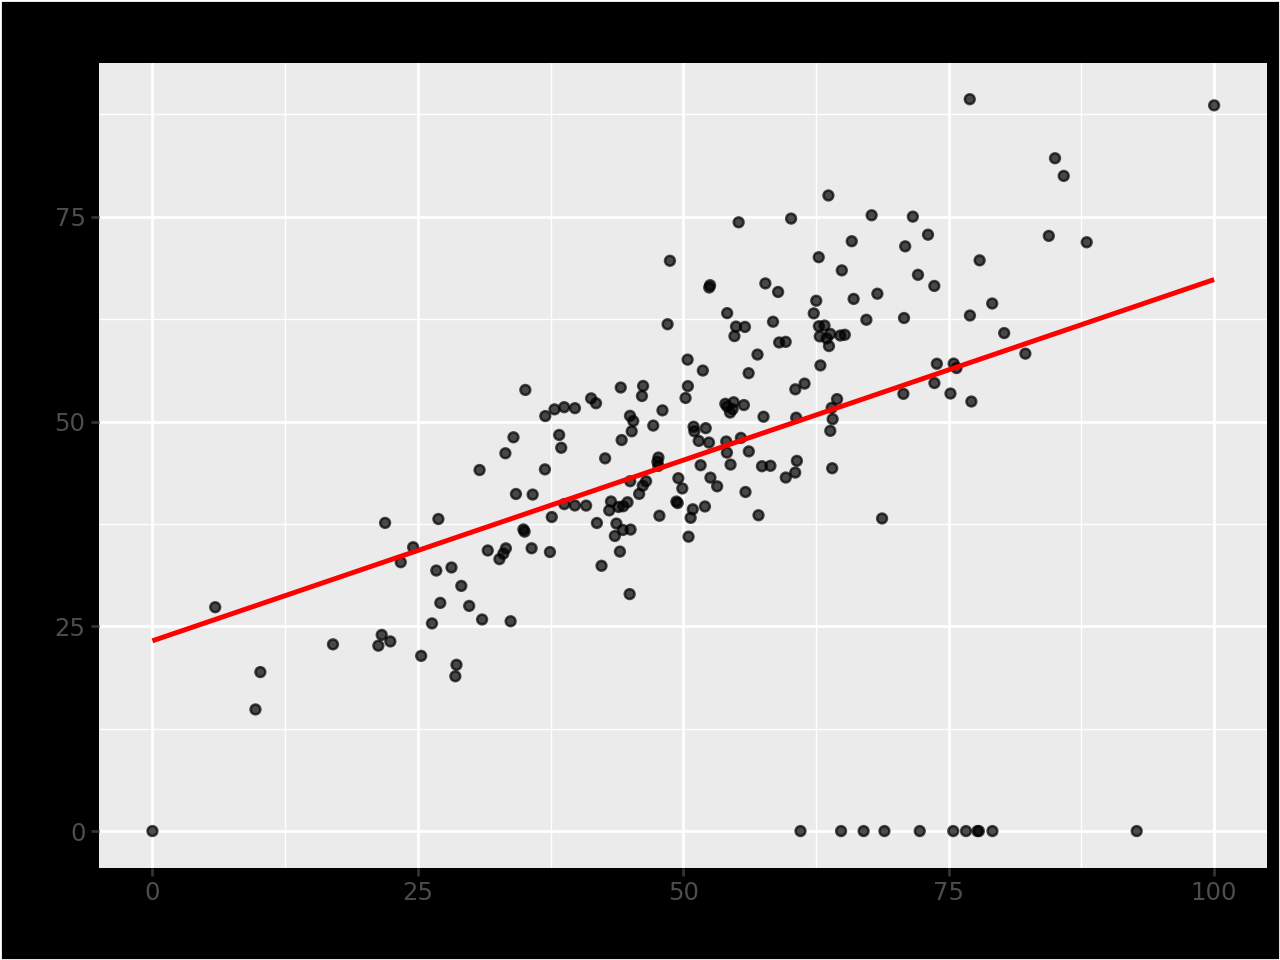

In [80]:
from scipy.stats import pearsonr

pearson_r, pearson_p = pearsonr(
    exam_correlation['attendance'],
    exam_correlation['achieved_points']
)

pearson_r, pearson_p

(
    ggplot(exam_correlation, aes(x='attendance', y='achieved_points'))
    + geom_point(alpha=0.7)
    + geom_smooth(method='lm', se=False, color='red')
    + labs(
        title="Attendance vs Points",
        x="Attendance",
        y="Points"
    )
)

0.5662806438724222 2.351267556601831e-18


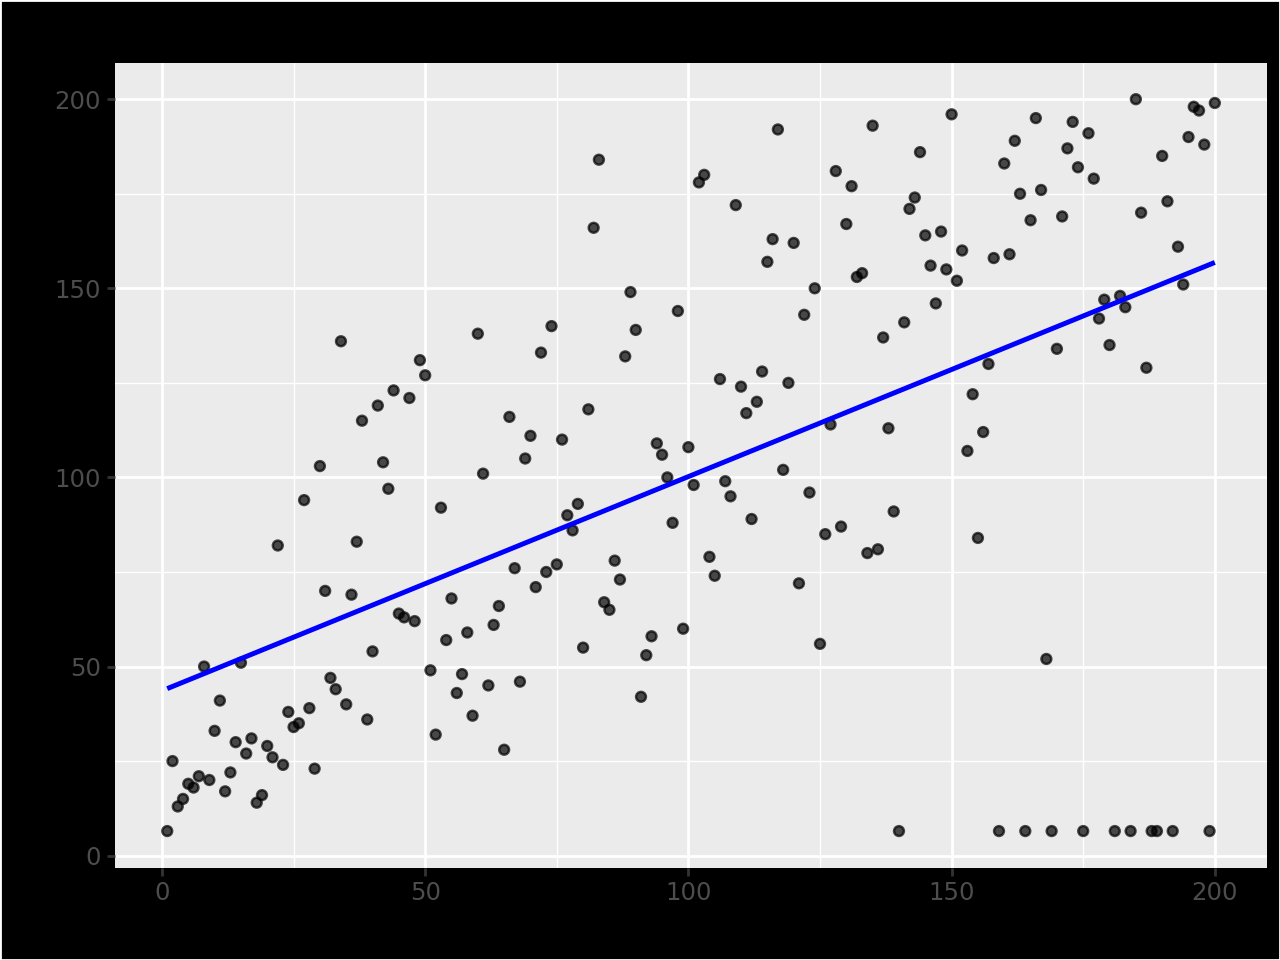

In [81]:
from scipy.stats import spearmanr

spearman_rho, spearman_p = spearmanr(
    exam_correlation['attendance'],
    exam_correlation['achieved_points']
)

print(spearman_rho, spearman_p)

exam_correlation_ranked = exam_correlation.copy()
exam_correlation_ranked['attendance_rank'] = exam_correlation['attendance'].rank()
exam_correlation_ranked['points_rank'] = exam_correlation['achieved_points'].rank()

(
    ggplot(exam_correlation_ranked,
           aes(x='attendance_rank', y='points_rank'))
    + geom_point(alpha=0.7)
    + geom_smooth(method='lm', se=False, color='blue')
    + labs(
        title="Ranked Attendance vs Ranked Points (Spearman)",
        x="Rank(attendance)",
        y="Rank(points)"
    )
)